In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import duckdb

In [2]:
df = pd.read_excel('data part 2 combined.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4211 entries, 0 to 4210
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          4211 non-null   int64  
 1   user_id                 4211 non-null   object 
 2   gift_id                 4211 non-null   int64  
 3   redeemed_at             4211 non-null   object 
 4   used_at                 3903 non-null   object 
 5   gift_category           4211 non-null   object 
 6   gift_price              4211 non-null   int64  
 7   merchant_discount_rate  4211 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 263.3+ KB


In [3]:
df['redeemed_at'] = pd.to_datetime(df['redeemed_at'])
df['used_at'] = pd.to_datetime(df['used_at'])

In [4]:
#Tìm khoảng thời gian chờ giữa thời điểm sử dụng và quy đổi voucher
df['delay_time'] = (df['used_at'] - df['redeemed_at']).dt.days

In [5]:
#Phần trăm số voucher chưa được sử dụng sau khi đã quy đổi trong tập dữ liệu
df['used_at'].isnull().sum()/df['redeemed_at'].count() * 100

np.float64(7.3141771550700545)

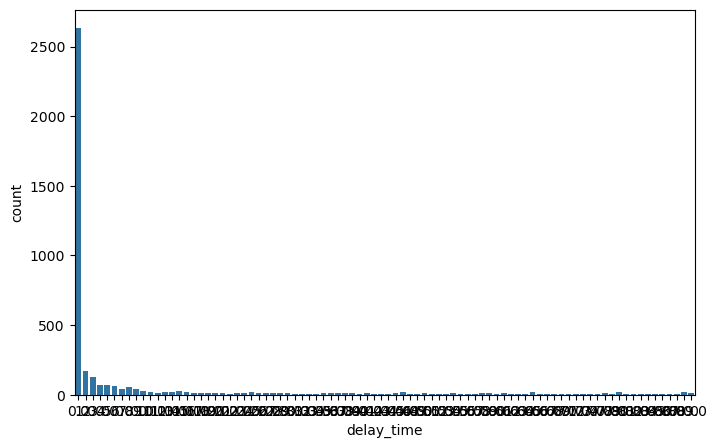

In [7]:
plt.figure(figsize = (8,5))
sns.countplot(df, x = 'delay_time')
plt.show()

In [8]:
df['delay_time'].describe()

count    3903.000000
mean        6.878811
std        17.020126
min         0.000000
25%         0.000000
50%         0.000000
75%         2.500000
max        89.000000
Name: delay_time, dtype: float64

*** Bài toán tăng tỷ lệ sử dụng voucher sau khi đã quy đổi used ratio = voucher used/ voucher redeemed
Dựa theo biểu đồ và những thống kê ở trên với khoảng thời gian khách trì hoãn sử dụng voucher đã quy đổi ta rút ra kết luận sau:
1.Khách hàng đa phần đều sử dụng voucher ngay sau khi quy đổi, chỉ có một số ít khách trì hoãn sử dụng (lí do có thể là quên)
=> để tăng tỷ lệ used ratio thì ta có thể nhắc nhở khách sử dụng voucher nếu như delay time vượt quá 7 ngày (theo con số trung bình 6.87)

*** Bài toán : Tăng tỷ lệ khách hàng sử dụng và ở lại với brand
Dựa theo bài toán ta đã giải quyết ở dữ liệu phần 1 ta có nhiều giải pháp để tăng số lượng giao dịch cũng như tăng số lượng brand sử dụng. 

In [10]:
df['profit'] = df['gift_price']* df['merchant_discount_rate']
df['Revenue']= df['gift_price']* (1 - df['merchant_discount_rate'])

In [14]:
k = df.groupby('gift_category', as_index = False).agg({'transaction_id':'count', 'user_id': 'nunique','merchant_discount_rate':'median','profit':'sum', 'Revenue':'sum','gift_price':'median'}).sort_values(by = 'transaction_id', ascending = False)
k.rename (columns = {'transaction_id':'Total transaction', 'user_id':'Total users','merchant_discount_rate':'Median_discount_rate','profit':'Total profit','gift_price':'median_gift_price'}, inplace = True)
k['Percentage_revenue%']= (k['Revenue']/k['Revenue'].sum()* 100).round(2)
k['Percentage_profit%']= (k['Total profit']/k['Total profit'].sum()* 100).round(2)
k

,gift_category,Total transaction,Total users,Median_discount_rate,Total profit,Revenue,median_gift_price,Percentage_revenue%,Percentage_profit%
4,Làm Đẹp - Sức Khoẻ,1680,440,0.10,78650760.0,710439240.0,500000.0,64.20,82.17
3,Hoa - Quả - Thực Phẩm Sạch,772,291,0.00,5000.0,38645000.0,50000.0,3.49,0.01
5,Nhà Hàng,562,165,0.02,800000.0,31310000.0,40000.0,2.83,0.84
7,Thời Trang - Phụ Kiện,539,191,0.10,14900000.0,138830000.0,500000.0,12.55,15.57
6,Siêu Thị - Điện Máy - Mẹ Và Bé,316,106,0.00,21000.0,158279000.0,500000.0,14.30,0.02
2,Du Lịch - Giải Trí,238,120,0.00,0.0,11900000.0,50000.0,1.08,0.00
1,Café - Thức Uống,79,42,0.07,1211000.0,16089000.0,200000.0,1.45,1.27
0,Bánh Kem - Đồ Ăn Vặt,25,5,0.10,125000.0,1125000.0,50000.0,0.10,0.13


*** Bài toán : Tăng trưởng lợi nhuận cho Urbox
Dựa theo bảng dữ liệu trên, ta thấy:
1. Nhu cầu sử dụng voucher chủ yếu nằm ở nhóm Làm đẹp -Sức khỏe và cũng là nhóm mang lại lợi nhuận nhiều nhất cho Urbox với chiết khấu cao (mức 10%), với ta tích cực cross-sales các mặt hàng trong ngành này nếu như khách hàng đã từng mua sản phẩm của một số brand trong ngành này. 
2. Ngoài ra nhóm ngành hàng Thời trang - phụ kiện cũng mang lại lợi nhuận chỉ sau nhóm Làm đẹp-sức khỏe, mệnh giá quy đổi và chiết khấu lớn (500000đ, 10%).
   => Với 2 ngành hàng có lợi nhuận lớn trên, ta sẽ ưu tiên chạy quảng cáo các voucher hời, hot deal trong ngày cho 2 ngành hàng này. Ngoài ra kết hợp với các giải pháp đã được đề ra ở Data part 1.
4. Nhóm Hoa quả-Thực phẩm sạch và Nhà hàng, Siêu thị điện máy-Mẹ và bé, Du lịch - Giải trí mang lại lợi nhuận khiêm tốn với tỷ lệ chiết khấu thấp (0-2%), tuy vậy các nhóm ngành hàng này lại có tỷ lệ sử dụng voucher cao chiếm 45%, doanh thu chiếm 21%. Nhóm này giúp làm tăng tỷ lệ hiệu quả cho App, với đa dạng nhóm brand và sản phẩm, ta có thể hướng tới việc cung cấp đề xuất, phân tích hành vi khách hàng cho đối tác của Urbox dựa trên lợi thế là App có lượng người dùng và số lượng giao dịch lớn.
5. Ngoài ra nếu có thêm thông tin về thời điểm tài khoản của khách hàng được kích hoạt (tổng tiền trong e-voucher lớn 0) và so sánh với thời gian lúc khách quy đổi ra voucher của 1 ngành hàng nào đó đầu tiên, ta có thể tận dụng đòn bẩy tài chính (lãi suất ngắn hạn) để khai thác lợi nhuận trong khoảng thời gian trống này. Hoặc số tiền mình đã thực nhận từ đối tác nhưng chưa phải thanh toán lại cho các brand, chạy dữ liệu trong 30-60-90 ngày để khai thác đòn bẩy tài chính ngắn hạn này. (bonus) 
6. Các ngành Cafe - Thức uống, Bánh kem-Đồ ăn vặt có tỷ lệ chiết khấu lớn, tiềm năng, ta có thể chạy một số gợi ý đi kèm nếu khách sử dụng voucher ở trung tâm thương mại hoặc một địa điểm có quy tụ các brand liên quan thì sẽ kích cầu sử dụng voucher cho khách hàng. (bonus)
7. Cho phép User nạp thêm tiền (Top-up) qua ví điện tử/ngân hàng để bù vào phần thiếu hụt khi đổi quà, ví dụ khách muốn đổi sản phẩm có giá trị 50k nhưng tài khoản chỉ còn 40k. Urbox sẽ có thêm khoản lợi nhuận nhờ hoa hồng và tăng số lượng giao dịch và độ trung thành với app.
8. Lập bảng dữ liệu cho thấy có bao nhiêu khách và số tiền quà tặng mà khách đã quá hạn nhưng chưa sử dụng => Về mặt logic thì số tiền này sẽ thành lợi nhuận ròng của Urbox, tuy vậy ta có thể thêm vào giải pháp gia hạn cho voucher quá hạn với mức phí tùy thuộc vào giá trị của gift.
   Nếu như khoảng thu từ phí gia hạn này cao hơn với với khoảng tiền bỏ quên của khách thì ta có thể áp dụng triển khai. 